# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup

This notebook converts the validated model output into a human-reviewed
content action playbook. The purpose is decision support, not automated content decisions.

The model ranks pages according to their measured probability of future
impression decline. Reason codes are then attached to make the queue easier
for a human reviewer to interpret.

The action recommendations are not causal claims. A high-risk page is a
page that is worth reviewing first, not a page that is guaranteed to improve
after a particular intervention.

In [1]:
import os
import getpass
import json
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

### Data source

This notebook uses the FlyRank warehouse release.

The daily fact table has grain:

`one client × one content page × one report date.`

The model uses a historical March 2026 feature window and an April 2026
future target window.

The April window is used only for validation/model evaluation. It is not
used to construct the features that generate the action queue.

In [2]:
HF_TOKEN = (os.environ.get("HF_TOKEN") or getpass.getpass("Paste your Hugging Face READ token (hf_...): "))

con = duckdb.connect()

con.execute(f"CREATE OR REPLACE SECRET hf " f"(TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients":                  f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content":                  f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily":                   f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_query_90d":               f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

Paste your Hugging Face READ token (hf_...): ··········


In [3]:
FEATURE_START = "2026-03-01"
FEATURE_END = "2026-04-01"

TARGET_START = "2026-04-01"
TARGET_END = "2026-05-01"

print("Feature window:", FEATURE_START, "to", FEATURE_END)
print("Target window:", TARGET_START, "to", TARGET_END)

Feature window: 2026-03-01 to 2026-04-01
Target window: 2026-04-01 to 2026-05-01


### Timeline
```text
Previous 30 days                  Future 30 days
───────────────────────┬────────────────────────
March 2026             │ April 2026
                       │
Historical features    │ Future outcome
Known at prediction    │ Used only for validation
                       │
                       ▼
                prediction moment
```
The action queue is constructed from March information only.
April information is used only when evaluating whether the model's
historical ranking corresponded to a later observed decline.

In [4]:
features = con.sql(
    f"""
    WITH feature_window AS (

        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS imp_prev30,
            SUM(gsc_clicks) AS clk_prev30,
            AVG(gsc_avg_position) AS avg_position_prev30,
            COUNT(*) FILTER (WHERE gsc_impressions > 0) AS days_with_impressions
        FROM {TABLES["fact_daily"]}
        WHERE report_date >= DATE '{FEATURE_START}' AND report_date < DATE '{FEATURE_END}' AND gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    )

    SELECT
        f.client_hash_id,
        f.content_hash_id,
        f.imp_prev30,
        f.clk_prev30,
        f.avg_position_prev30,
        f.days_with_impressions,
        DATE_DIFF('day', c.content_created_date, DATE '{TARGET_START}') AS content_age_days
    FROM feature_window f
    LEFT JOIN {TABLES["dim_content"]} c
        ON f.client_hash_id = c.client_hash_id AND f.content_hash_id = c.content_hash_id
    WHERE f.imp_prev30 >= 100
    """
).df()

print("Feature rows:", f"{len(features):,}")
display(features.head())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature rows: 101,441


,client_hash_id,content_hash_id,imp_prev30,clk_prev30,avg_position_prev30,days_with_impressions,content_age_days
0,client_0797ff3a1fc9a6a5,content_04c67f3541177192,331.0,2.0,14.129210,31,176
1,client_0797ff3a1fc9a6a5,content_0f30e04e709c7b5d,145.0,0.0,8.470926,30,176
2,client_0797ff3a1fc9a6a5,content_1207efddce873942,461.0,0.0,14.859827,31,176
3,client_0797ff3a1fc9a6a5,content_167472cd0802a8f3,232.0,0.0,12.297523,29,176
4,client_0797ff3a1fc9a6a5,content_27f8100281413b37,464.0,0.0,9.554793,18,176


In [5]:
future_outcomes = con.sql(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS imp_next30,
        SUM(gsc_clicks) AS clk_next30
    FROM {TABLES["fact_daily"]}
    WHERE report_date >= DATE '{TARGET_START}' AND report_date < DATE '{TARGET_END}' AND gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
    """
).df()

print("Future outcome rows:", f"{len(future_outcomes):,}")
display(future_outcomes.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Future outcome rows: 194,760


,client_hash_id,content_hash_id,imp_next30,clk_next30
0,client_62f4a7e64f5e0096,content_76c1f31e2b38f054,249.0,1.0
1,client_62f4a7e64f5e0096,content_ffc5ab4b34aab1f8,281.0,0.0
2,client_62f4a7e64f5e0096,content_9739856fc83dc1ca,722.0,0.0
3,client_62f4a7e64f5e0096,content_3d1dc691a3502105,3068.0,1.0
4,client_62f4a7e64f5e0096,content_9d28af4f99c5e67b,3896.0,3.0


In [6]:
data = features.merge(future_outcomes, on=["client_hash_id", "content_hash_id"], how="inner")

print("Final modeling rows:", f"{len(data):,}")
display(data.head())

Final modeling rows: 100,893


,client_hash_id,content_hash_id,imp_prev30,clk_prev30,avg_position_prev30,days_with_impressions,content_age_days,imp_next30,clk_next30
0,client_0797ff3a1fc9a6a5,content_04c67f3541177192,331.0,2.0,14.129210,31,176,561.0,3.0
1,client_0797ff3a1fc9a6a5,content_0f30e04e709c7b5d,145.0,0.0,8.470926,30,176,23.0,0.0
2,client_0797ff3a1fc9a6a5,content_1207efddce873942,461.0,0.0,14.859827,31,176,964.0,0.0
3,client_0797ff3a1fc9a6a5,content_167472cd0802a8f3,232.0,0.0,12.297523,29,176,248.0,0.0
4,client_0797ff3a1fc9a6a5,content_27f8100281413b37,464.0,0.0,9.554793,18,176,1138.0,0.0


In [7]:
data["impression_change_pct"] = (data["imp_next30"] - data["imp_prev30"]) / data["imp_prev30"]
data["is_declining"] = (data["impression_change_pct"] < -0.20).astype(int)

print(data["is_declining"].value_counts().rename({0: "not_declining", 1: "declining"}))
print("\nDecline rate:")
print(round(data["is_declining"].mean(), 4))

is_declining
declining        51944
not_declining    48949
Name: count, dtype: int64

Decline rate:
0.5148


In [8]:
feature_cols = [
    "imp_prev30",
    "clk_prev30",
    "avg_position_prev30",
    "days_with_impressions",
    "content_age_days",
]

model_data = data.dropna(subset=feature_cols + ["is_declining"]).copy()
print("Model rows:", f"{len(model_data):,}")

Model rows: 100,893


In [11]:
X = model_data[feature_cols]
y = model_data["is_declining"]

model = Pipeline(
    steps=[("scaler", StandardScaler()),
           ("classifier", LogisticRegression(max_iter=1000, random_state=42))])

model.fit(X, y)
model_data["decline_probability"] = model.predict_proba(X)[:, 1]

print("Model fitted.")

Model fitted.


### Important validation note

The probabilities generated here are used to construct a decision-support
queue from the available historical slice.

They should not be interpreted as perfectly calibrated probabilities.

The Week-6 validation work showed why grouped/time-aware validation matters.
Therefore, this queue is intended to prioritize human review rather than
automate decisions.

In [15]:
model_data["baseline_stale"] = (model_data["content_age_days"] >= 180).astype(int)
model_data["baseline_visible"] = (model_data["imp_prev30"] >= 500).astype(int)
model_data["baseline_score"] = model_data["baseline_stale"] * model_data["baseline_visible"] * model_data["imp_prev30"]

In [17]:
model_data["model_rank"] = model_data["decline_probability"].rank(method="first", ascending=False).astype(int)
model_data["baseline_rank"] = model_data["baseline_score"].rank(method="first", ascending=False).astype(int)
model_data = model_data.sort_values("decline_probability", ascending=False).reset_index(drop=True)

In [20]:
def assign_reason(row):

    if (row["decline_probability"] >= 0.60 and row["imp_prev30"] >= 500 and row["content_age_days"] >= 180):
        return "high_risk_stale_visible"
    elif (
        row["decline_probability"] >= 0.60 and row["avg_position_prev30"] >= 20
    ):
        return "high_risk_position"

    elif (
        row["decline_probability"] >= 0.60 and row["imp_prev30"] >= 5000
    ):
        return "high_risk_high_exposure"

    else:
        return "high_risk_general_review"


model_data["reason_code"] = model_data.apply(assign_reason, axis=1)

### Action policy

The model does not automatically choose a content intervention.

Instead, each reason code points the reviewer toward a different
diagnostic question.

The recommended actions are:

>- `high_risk_stale_visible` → review freshness and content relevance
>- `high_risk_position` → review search intent, relevance and SERP competition
>- `high_risk_high_exposure` → prioritize because a decline could affect
>  a page with substantial historical visibility
>- `high_risk_general_review` → broader manual review before deciding

These are decision-support recommendations, not causal prescriptions.

In [21]:
action_map = {
    "high_risk_stale_visible": "Review freshness and content relevance",
    "high_risk_position": "Review search intent, relevance and ranking context",
    "high_risk_high_exposure": "Prioritize for manual performance review",
    "high_risk_general_review": "Conduct broader manual content review",
}

model_data["suggested_action"] = model_data["reason_code"].map(action_map)

In [22]:
def confidence_note(row):

    p = row["decline_probability"]
    if p >= 0.80:
        return "High model score; still requires human review"
    elif p >= 0.60:
        return "Moderately high model score; review before action"
    else:
        return "Lower model score; monitor or deprioritize"

model_data["confidence_note"] = model_data.apply(confidence_note, axis=1)

In [24]:
queue_cols = [
    "client_hash_id",
    "content_hash_id",

    "model_rank",
    "decline_probability",

    "reason_code",
    "suggested_action",
    "confidence_note",

    "imp_prev30",
    "clk_prev30",
    "avg_position_prev30",
    "days_with_impressions",
    "content_age_days",
]

queue = model_data[queue_cols].sort_values("model_rank").reset_index(drop=True)
queue.head(20)

,client_hash_id,content_hash_id,model_rank,decline_probability,reason_code,suggested_action,confidence_note,imp_prev30,clk_prev30,avg_position_prev30,days_with_impressions,content_age_days
0,client_23a62021009f63c4,content_44f34c0a90047651,1,0.973432,high_risk_high_exposure,Prioritize for manual performance review,High model score; still requires human review,212404.0,24.0,7.346909,31,70
1,client_73cda7b4e4f265ea,content_8e1334d6356668e3,2,0.932084,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,134984.0,1.0,4.545582,31,411
2,client_73cda7b4e4f265ea,content_fec55986a1868d62,3,0.918500,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,124075.0,1.0,9.385150,31,411
3,client_23a62021009f63c4,content_bdf60c86117079be,4,0.883043,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,112429.0,12.0,30.769353,31,231
4,client_23a62021009f63c4,content_559cdd76da9306de,5,0.876590,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,97378.0,2.0,36.712074,31,217
5,client_62f4a7e64f5e0096,content_34a70fea29d15f24,6,0.875231,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,143019.0,43.0,3.219473,31,279
6,client_62f4a7e64f5e0096,content_f6116743b00afc2d,7,0.872980,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,107584.0,15.0,9.536301,31,194
7,client_23a62021009f63c4,content_164c1f53f13bcee1,8,0.870164,high_risk_position,"Review search intent, relevance and ranking co...",High model score; still requires human review,89982.0,2.0,24.083947,31,84
8,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,9,0.856085,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,83834.0,1.0,11.195379,31,244
9,client_9958f0a7ae1df715,content_cd3d932d4e1c8db0,10,0.852039,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,89332.0,4.0,7.786219,31,448


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*


The ranked queue is ordered by the model's measured decline-risk score.

Pages near the top are not automatically considered to require a refresh.
They are pages that the model ranks as higher priority for human review.

The reason code provides the main historical signal that explains why a
page is being surfaced.

Reason codes:

1. `high_risk_stale_visible`
   - Higher model score
   - At least 500 historical impressions
   - At least 180 days since update
   - Suggested action: review freshness and relevance

2. `high_risk_position`
   - Higher model score
   - Historical average position >= 20
   - Suggested action: review search intent, relevance and ranking context

3. `high_risk_high_exposure`
   - Higher model score
   - At least 5,000 historical impressions
   - Suggested action: prioritize for manual performance review

4. `high_risk_general_review`
   - Higher model score without one dominant diagnostic signal
   - Suggested action: broader manual review

These reason codes describe observed historical signals. They do not explain
the causal reason why a page will decline.

In [25]:
reason_summary = (
    queue
    .groupby("reason_code")
    .agg(
        n=("content_hash_id", "size"),
        median_model_score=("decline_probability", "median"),
        median_impressions=("imp_prev30", "median"),
        median_age=("content_age_days", "median"),
    )
    .reset_index()
    .sort_values(
        "median_model_score",
        ascending=False
    )
)

display(reason_summary)

,reason_code,n,median_model_score,median_impressions,median_age
1,high_risk_high_exposure,730,0.615682,8689.5,86.0
3,high_risk_stale_visible,1131,0.607872,8215.0,218.0
2,high_risk_position,1088,0.606613,5705.5,78.0
0,high_risk_general_review,97944,0.558665,749.0,189.0


In [27]:
top20 = queue.head(20).copy()

display(
    top20[
        [
            "model_rank",
            "content_hash_id",
            "decline_probability",
            "reason_code",
            "suggested_action",
            "confidence_note",
            "imp_prev30",
            "avg_position_prev30",
            "content_age_days"
        ]
    ]
)

,model_rank,content_hash_id,decline_probability,reason_code,suggested_action,confidence_note,imp_prev30,avg_position_prev30,content_age_days
0,1,content_44f34c0a90047651,0.973432,high_risk_high_exposure,Prioritize for manual performance review,High model score; still requires human review,212404.0,7.346909,70
1,2,content_8e1334d6356668e3,0.932084,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,134984.0,4.545582,411
2,3,content_fec55986a1868d62,0.918500,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,124075.0,9.385150,411
3,4,content_bdf60c86117079be,0.883043,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,112429.0,30.769353,231
4,5,content_559cdd76da9306de,0.876590,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,97378.0,36.712074,217
5,6,content_34a70fea29d15f24,0.875231,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,143019.0,3.219473,279
6,7,content_f6116743b00afc2d,0.872980,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,107584.0,9.536301,194
7,8,content_164c1f53f13bcee1,0.870164,high_risk_position,"Review search intent, relevance and ranking co...",High model score; still requires human review,89982.0,24.083947,84
8,9,content_9c057b66c30a3abb,0.856085,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,83834.0,11.195379,244
9,10,content_cd3d932d4e1c8db0,0.852039,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,89332.0,7.786219,448


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

The queue is intended for SEO/content teams that need to decide which
pages to inspect first.

It can help reduce a large content portfolio into a smaller review queue.

The model is most useful as decision support:

- identify pages with higher measured decline risk
- prioritize manual inspection
- provide historical context for the review
- help allocate limited review capacity

### Limits

The queue does not determine whether a page should definitely be refreshed.

A high score does not establish that a page will decline.

A high score also does not establish that refreshing the page would
prevent the decline.

The model was developed using one historical feature window and one future
validation window. Performance may change for other periods, clients,
industries or search environments.

The warehouse is an unbalanced panel, so pages and clients do not all have
the same historical coverage.

The model should therefore be treated as decision-support rather than
an autonomous content-management system.

In [29]:
decay_audit = (
    model_data
    .assign(
        freshness_bucket=pd.cut(
            model_data["content_age_days"],
            bins=[-1, 90, 180, 365, 10000],
            labels=[
                "<=90 days",
                "91-180 days",
                "181-365 days",
                ">365 days"
            ]
        )
    )
    .groupby(
        "freshness_bucket",
        observed=True
    )
    .agg(
        n=("content_hash_id", "size"),
        median_impressions=("imp_prev30", "median"),
        mean_decline_risk=("decline_probability", "mean"),
    )
    .reset_index()
)

decay_audit["mean_decline_risk"] *= 100

display(decay_audit)

,freshness_bucket,n,median_impressions,mean_decline_risk
0,<=90 days,33070,745.0,46.629320
1,91-180 days,16075,985.0,55.045970
2,181-365 days,37434,881.5,53.831338
3,>365 days,14314,595.0,52.542126


### Decay/refresh interpretation

This table is descriptive rather than causal.

If older freshness buckets show higher measured model risk, the appropriate
interpretation is that staleness is associated with higher observed
decision-support priority in this dataset.

It does not show that updating a page will cause its performance to improve.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review rules

Before taking action on a page in the queue, a reviewer should check:

1. Search intent
   - Does the current page still match the query intent?

2. Content relevance
   - Is the information still useful and accurate?

3. Freshness
   - Has the topic changed since the page was last updated?

4. Search context
   - Are competitors or SERP features changing the opportunity?

5. Historical evidence
   - Is the observed decline risk supported by meaningful historical
     search exposure?

6. Business context
   - Is the page strategically important?

7. Technical issues
   - Are indexing, canonical, migration or tracking issues involved?

8. Measurement quality
   - Is the apparent performance change based on sufficient observed data?

The reviewer should record the final action separately from the model's
recommendation.


---


### Possible human decisions

- Refresh content
- Investigate technical/search issues
- Monitor without intervention
- Leave unchanged
- Escalate for specialist review


---


### What should NOT be automated

The system should not automatically:

- publish content changes
- rewrite a page
- delete a page
- change search intent
- change canonical URLs
- change internal linking strategy
- change metadata without review
- declare a page a ranking failure
- claim that a refresh will improve traffic
- make business-priority decisions without human context

In [30]:
no_go_items = pd.DataFrame({
    "Decision": [
        "Publish content automatically",
        "Delete a page automatically",
        "Rewrite search intent automatically",
        "Change canonical automatically",
        "Claim refresh will improve traffic",
        "Declare Google ranking cause",
        "Override business priorities"
    ],
    "Allowed": [
        "NO",
        "NO",
        "NO",
        "NO",
        "NO",
        "NO",
        "NO"
    ],
    "Reason": [
        "Requires human quality review",
        "Requires business and content context",
        "Requires intent and SERP analysis",
        "Requires technical SEO review",
        "Model is observational/decision-support",
        "Dataset does not identify Google's causal mechanism",
        "Business context is outside the model"
    ]
})

display(no_go_items)

,Decision,Allowed,Reason
0,Publish content automatically,NO,Requires human quality review
1,Delete a page automatically,NO,Requires business and content context
2,Rewrite search intent automatically,NO,Requires intent and SERP analysis
3,Change canonical automatically,NO,Requires technical SEO review
4,Claim refresh will improve traffic,NO,Model is observational/decision-support
5,Declare Google ranking cause,NO,Dataset does not identify Google's causal mech...
6,Override business priorities,NO,Business context is outside the model


### Cost/value thinking

The queue is most useful when human review capacity is limited.

The main value comes from concentrating review effort on a smaller set of
pages with higher measured risk.

A simple operational decision is:

    expected review value
        versus
    cost of reviewing the page

The model does not estimate financial value directly.

Therefore, a high model score should not automatically imply high business
priority.

For example:

- A high-risk page with very little traffic may have limited immediate value.
- A moderately high-risk page with substantial historical visibility may
  deserve earlier review.
- A strategically important page may deserve review even if the model score
  is modest.

The model supplies one piece of evidence; business value remains a human
decision.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The model should not be assumed to remain equally useful forever.

Monitoring should focus on both the data and the ranking performance.

### Trigger 1 — Prediction performance

Recalculate Precision@K periodically.

For example:

- Precision@20
- Precision@50

If precision falls materially relative to the validated benchmark, investigate
before continuing to use the queue.

### Trigger 2 — Base-rate shift

Monitor the observed decline rate.

A substantial change in the proportion of declining pages may indicate that
the environment has changed.

### Trigger 3 — Feature distribution shift

Monitor:

- impressions
- clicks
- average position
- days with impressions
- content age

Large changes in their distributions may mean that the model is operating
outside the conditions under which it was developed.

### Trigger 4 — Missingness / tracking changes

Monitor GSC availability.

A change in tracking coverage can change the meaning of the features.

### Trigger 5 — Portfolio changes

If the client portfolio or content mix changes substantially, the model
should be re-evaluated.

### Trigger 6 — Decision quality

Human reviewers should periodically sample both:

- high-ranked pages
- low-ranked pages

If high-ranked pages are consistently judged irrelevant while important
pages are missed, the ranking logic should be reviewed.

### Retraining trigger

Retraining should be considered when:

- out-of-sample Precision@K deteriorates materially,
- feature distributions shift materially,
- decline base rate changes substantially,
- GSC availability changes,
- or the content/client population changes substantially.

The exact threshold should be chosen after collecting operational monitoring
data rather than invented in advance.

In [39]:
monitoring_snapshot = {
    "n_pages": int(len(model_data)),
    "decline_rate": float(model_data["is_declining"].mean()),
    "median_impressions": float(model_data["imp_prev30"].median()),
    "median_clicks": float(model_data["clk_prev30"].median()),
    "median_position": float(model_data["avg_position_prev30"].median()),
    "median_content_age": float(model_data["content_age_days"].median())
}

monitoring_snapshot

{'n_pages': 100893,
 'decline_rate': 0.5148424568602381,
 'median_impressions': 794.0,
 'median_clicks': 1.0,
 'median_position': 8.720766322112373,
 'median_content_age': 188.0}

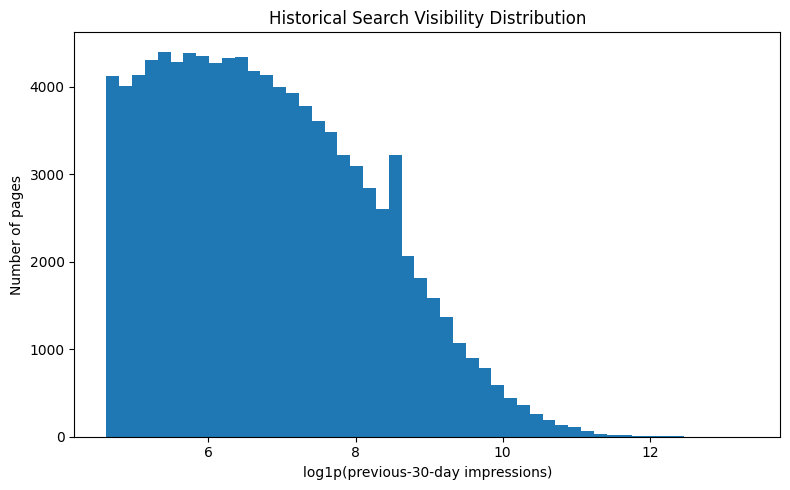

In [31]:
plt.figure(figsize=(8, 5))

plt.hist(np.log1p(model_data["imp_prev30"]), bins=50)

plt.xlabel("log1p(previous-30-day impressions)")
plt.ylabel("Number of pages")
plt.title("Historical Search Visibility Distribution")

plt.tight_layout()

FIG_DIR = Path("work/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    FIG_DIR / "historical_visibility_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [35]:
OUTPUT_DIR = Path("work/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

queue_path = OUTPUT_DIR / "baseline_action_score.csv"

queue.to_csv(
    queue_path,
    index=False
)

print("Queue written to:")
print(queue_path)

Queue written to:
work/outputs/baseline_action_score.csv


In [36]:
top20_path = OUTPUT_DIR / "top20_action_review.csv"

top20.to_csv(top20_path, index=False)

print("Top-20 review written to:")
print(top20_path)

Top-20 review written to:
work/outputs/top20_action_review.csv


In [40]:
metrics_path = OUTPUT_DIR / "action_playbook_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(monitoring_snapshot, f, indent=2)

print("Metrics written to:")
print(metrics_path)

Metrics written to:
work/outputs/action_playbook_metrics.json


In [41]:
reason_path = OUTPUT_DIR / "reason_code_summary.csv"

reason_summary.to_csv(
    reason_path,
    index=False
)

print("Reason summary written to:")
print(reason_path)

Reason summary written to:
work/outputs/reason_code_summary.csv


In [42]:
print("Files created:")
for path in [
    queue_path,
    top20_path,
    metrics_path,
    reason_path,
    FIG_DIR / "historical_visibility_distribution.png",
]:
    print(" -", path, "| exists:", path.exists())

Files created:
 - work/outputs/baseline_action_score.csv | exists: True
 - work/outputs/top20_action_review.csv | exists: True
 - work/outputs/action_playbook_metrics.json | exists: True
 - work/outputs/reason_code_summary.csv | exists: True
 - work/figures/historical_visibility_distribution.png | exists: True


In [43]:
display(queue.head(20))

,client_hash_id,content_hash_id,model_rank,decline_probability,reason_code,suggested_action,confidence_note,imp_prev30,clk_prev30,avg_position_prev30,days_with_impressions,content_age_days
0,client_23a62021009f63c4,content_44f34c0a90047651,1,0.973432,high_risk_high_exposure,Prioritize for manual performance review,High model score; still requires human review,212404.0,24.0,7.346909,31,70
1,client_73cda7b4e4f265ea,content_8e1334d6356668e3,2,0.932084,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,134984.0,1.0,4.545582,31,411
2,client_73cda7b4e4f265ea,content_fec55986a1868d62,3,0.918500,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,124075.0,1.0,9.385150,31,411
3,client_23a62021009f63c4,content_bdf60c86117079be,4,0.883043,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,112429.0,12.0,30.769353,31,231
4,client_23a62021009f63c4,content_559cdd76da9306de,5,0.876590,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,97378.0,2.0,36.712074,31,217
5,client_62f4a7e64f5e0096,content_34a70fea29d15f24,6,0.875231,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,143019.0,43.0,3.219473,31,279
6,client_62f4a7e64f5e0096,content_f6116743b00afc2d,7,0.872980,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,107584.0,15.0,9.536301,31,194
7,client_23a62021009f63c4,content_164c1f53f13bcee1,8,0.870164,high_risk_position,"Review search intent, relevance and ranking co...",High model score; still requires human review,89982.0,2.0,24.083947,31,84
8,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,9,0.856085,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,83834.0,1.0,11.195379,31,244
9,client_9958f0a7ae1df715,content_cd3d932d4e1c8db0,10,0.852039,high_risk_stale_visible,Review freshness and content relevance,High model score; still requires human review,89332.0,4.0,7.786219,31,448


This notebook produces the following artifacts:

### Ranked queue

`work/outputs/baseline_action_score.csv`

Contains the ranked decision-support queue with:

- pseudonymized client ID
- pseudonymized content ID
- model rank
- model score
- reason code
- suggested action
- confidence note
- historical feature context

### Top-20 review

`work/outputs/top20_action_review.csv`

Contains the highest-ranked pages for manual inspection.

### Reason-code summary

`work/outputs/reason_code_summary.csv`

Summarizes the size and historical characteristics of each reason-code
group.

### Monitoring snapshot

`work/outputs/action_playbook_metrics.json`

Stores the current data-quality and portfolio statistics used for future
monitoring.

### Figure

`work/figures/historical_visibility_distribution.png`

Shows the heavy-tailed distribution of historical search visibility.

                 MODEL
                   │
                   ▼
        decline_probability
                   │
                   ▼
              RANK PAGES
                   │
                   ▼
        ┌───────────────────┐
        │  REVIEW CONTEXT   │
        ├───────────────────┤
        │ visibility        │
        │ staleness         │
        │ position          │
        │ content age       │
        └───────────────────┘
                   │
                   ▼
             REASON CODE
                   │
                   ▼
          SUGGESTED ACTION
                   │
                   ▼
             HUMAN REVIEW
                   │
          ┌────────┴────────┐
          ▼                 ▼
       TAKE ACTION       NO ACTION

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.